In [1]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as BaseDataset
from pathlib import Path
import os
import cv2
import numpy as np
import albumentations as A

/home/user/software/anaconda3/envs/hry/lib/python3.12/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error _ssl.c:993: The handshake operation timed out>
  data = fetch_version_info()


In [2]:
# git clone https://github.com/alexgkendall/SegNet-Tutorial ./data

In [3]:
DATA_DIR = Path("../data/CamVid/")

x_train_dir = DATA_DIR / "train"
y_train_dir = DATA_DIR / "trainannot"

x_valid_dir = DATA_DIR / "val"
y_valid_dir = DATA_DIR / "valannot"

x_test_dir = DATA_DIR / "test"
y_test_dir = DATA_DIR / "testannot"

(360, 480)
1
[ 0  1  2  3  4  5  6  8  9 11]


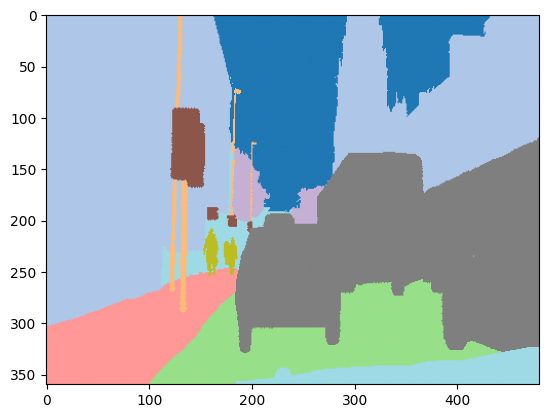

In [4]:
img = cv2.imread(y_train_dir / "0001TP_006690.png", 0)
print(img.shape)
print(img[0][111])
print(np.unique(img))
plt.imshow(img, cmap='tab20')

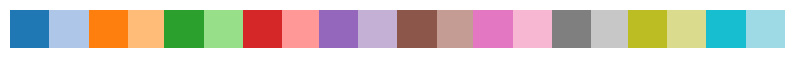

In [5]:
plt.figure(figsize=(10, 0.5))
plt.axis('off')
plt.imshow(np.linspace(0,1,256).reshape(1,-1), aspect='auto', cmap='tab20')

In [6]:
CLASSES = [
    "sky",
    "building",
    "pole",
    "road",
    "pavement",
    "tree",
    "signsymbol",
    "fence",
    "car",
    "pedestrian",
    "bicyclist",
    "unlabelled",
]

In [7]:
s = set()
s.add((1,2))
s.add((1,2))
print(s)

{(1, 2)}


In [8]:
class Dataset(BaseDataset):
    CLASSES = [
        "sky",
        "building",
        "pole",
        "road",
        "pavement",
        "tree",
        "signsymbol",
        "fence",
        "car",
        "pedestrian",
        "bicyclist",
        "unlabelled",
    ]

    def __init__(self, images_dir:Path, masks_dir:Path, classes:list=None, augmentation=None):
        self.ids = os.listdir(images_dir)
        self.images_fps = [images_dir / image_id for image_id in self.ids]
        self.masks_fps = [masks_dir / image_id for image_id in self.ids]

        # Always map background ('unlabelled') to 0
        self.background_class = self.CLASSES.index("unlabelled")

        # If specific classes are provided, map them dynamically
        if classes:
            self.class_values = [self.CLASSES.index(cls.lower()) for cls in classes]
        else:
            self.class_values = list(range(len(self.CLASSES)))  # Default to all classes

        # Create a remapping dictionary: class value in dataset -> new index (0, 1, 2, ...)
        # Background will always be 0, other classes will be remapped starting from 1.
        self.class_map = {self.background_class: 0}
        self.class_map.update(
            {v: i + 1 for i, v in enumerate(self.class_values) if v != self.background_class}
        )

        self.augmentation = augmentation

    def __getitem__(self, i):
        # Read the image
        image = cv2.imread(self.images_fps[i])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

        # Read the mask in grayscale mode
        mask = cv2.imread(self.masks_fps[i], 0)

        # Create a blank mask to remap the class values
        mask_remap = np.zeros_like(mask)

        # Remap the mask according to the dynamically created class map
        for class_value, new_value in self.class_map.items():
            mask_remap[mask == class_value] = new_value

        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask_remap)
            image, mask_remap = sample["image"], sample["mask"]
        image = image.transpose(2, 0, 1)
        return image, mask_remap

    def __len__(self):
        return len(self.ids)

In [9]:
def visualize(**images):
    """Plot images in one row."""
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(" ".join(name.split("_")).title())

        # If it's an image, plot it as RGB
        if name == "image":
            # Convert CHW to HWC for plotting
            image = image.transpose(1, 2, 0)
            plt.imshow(image)
        else:
            plt.imshow(image, cmap="tab20")
    plt.show()

Mask shape: (360, 480)


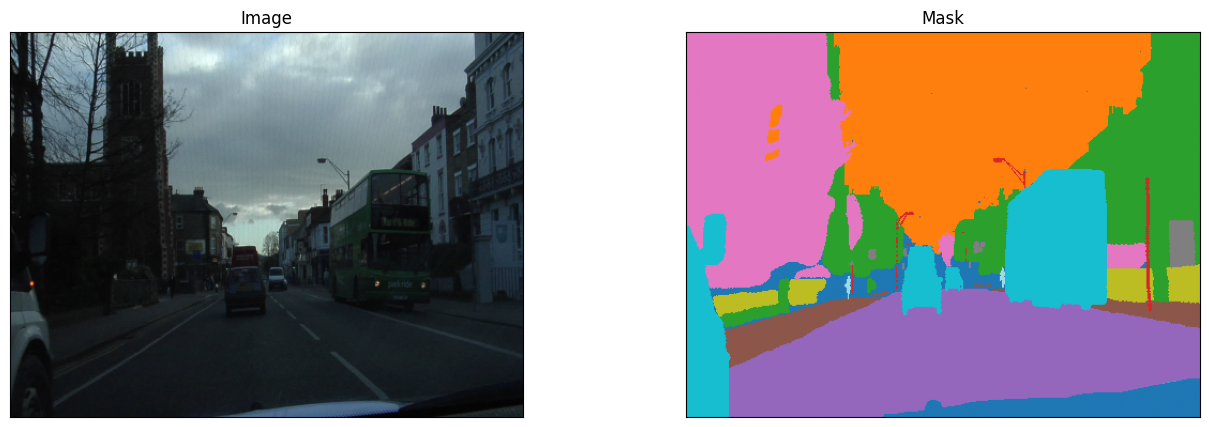

In [10]:
dataset = Dataset(x_train_dir, y_train_dir)
image, mask = dataset[0]
print(f"Mask shape: {mask.shape}")
visualize(image=image, mask=mask)

In [ ]:
# training set images augmentation
def get_training_augmentation():
    train_transform = [
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            scale_limit=0.5, rotate_limit=0, shift_limit=0.1, p=1, border_mode=0
        ),
        A.PadIfNeeded(min_height=320, min_width=320, always_apply=True),
        A.RandomCrop(height=320, width=320, p=1),
        A.GaussNoise(p=0.2),
        A.Perspective(p=0.5),
        A.OneOf(
            [
                A.CLAHE(p=1),
                A.RandomBrightnessContrast(p=1),
                A.RandomGamma(p=1),
            ],
            p=0.9,
        ),
        A.OneOf(
            [
                A.Sharpen(p=1),
                A.Blur(blur_limit=3, p=1),
                A.MotionBlur(blur_limit=3, p=1),
            ],
            p=0.9,
        ),
        A.OneOf(
            [
                A.RandomBrightnessContrast(p=1),
                A.HueSaturationValue(p=1),
            ],
            p=0.9,
        ),
    ]
    return A.Compose(train_transform)


def get_validation_augmentation():
    """
    Add paddings to make image shape divisible by 32
    原图尺寸为360x480
    """
    test_transform = [
        A.PadIfNeeded(384, 480),
    ]
    return A.Compose(test_transform)

/tmp/ipykernel_134129/1551156842.py:8: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=320, min_width=320, always_apply=True),


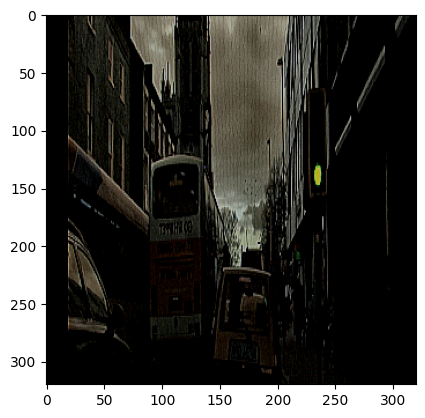

In [26]:
image = cv2.imread(x_train_dir / "0001TP_006690.png")
mask = cv2.imread(y_train_dir / "0001TP_006690.png", 0)

augment = get_training_augmentation()
sample = augment(image=image, mask=mask)
plt.imshow(sample["image"])

/tmp/ipykernel_134129/1551156842.py:8: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=320, min_width=320, always_apply=True),


Mask shape: (320, 320)
[ 0  1  2  3  4  5  6  7  8  9 10 11]


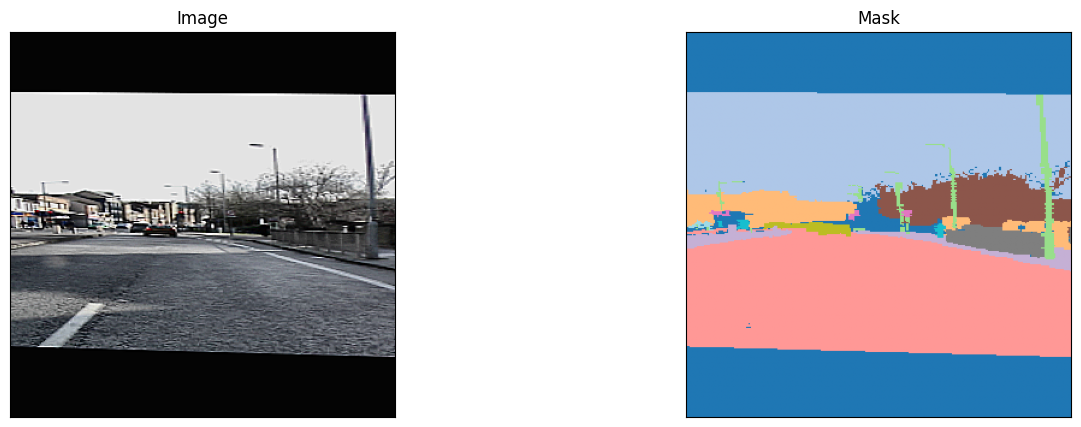

Mask shape: (320, 320)
[ 0  1  2  3  4  5  6  7  8  9 10 11]


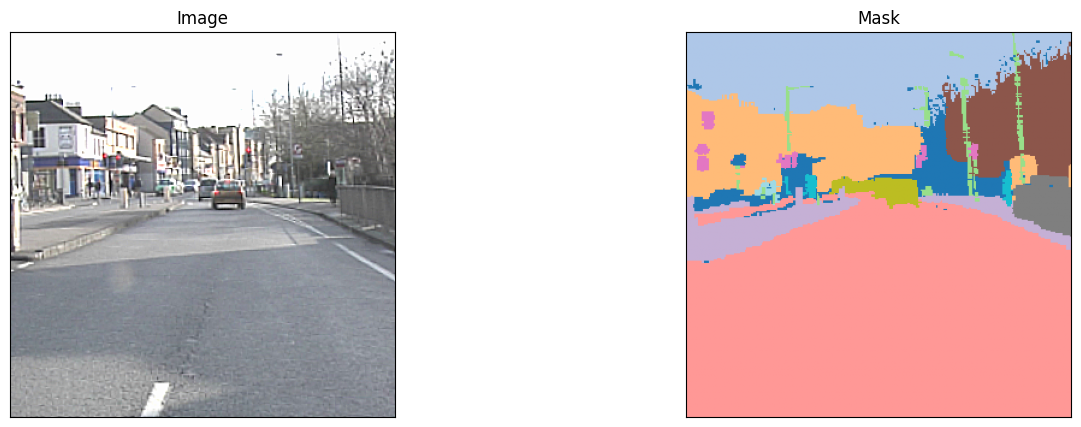

Mask shape: (320, 320)
[ 0  1  2  3  4  5  6  7  8  9 10 11]


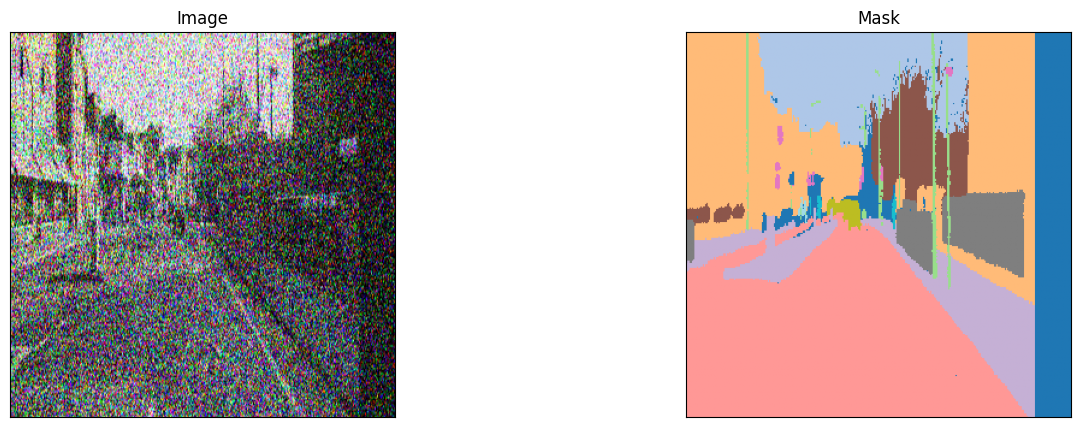

In [27]:
# Visualize resulted augmented images and masks
augmented_dataset = Dataset(
    x_train_dir,
    y_train_dir,
    augmentation=get_training_augmentation(),
)

# Visualizing the same image with different random transforms
for i in range(3):
    image, mask = augmented_dataset[3]
    print(f"Mask shape: {mask.shape}")
    print(np.unique(mask))
    visualize(image=image, mask=mask)

Mask shape: (384, 480)
[ 0  1  2  3  4  5  6  7  8  9 10 11]


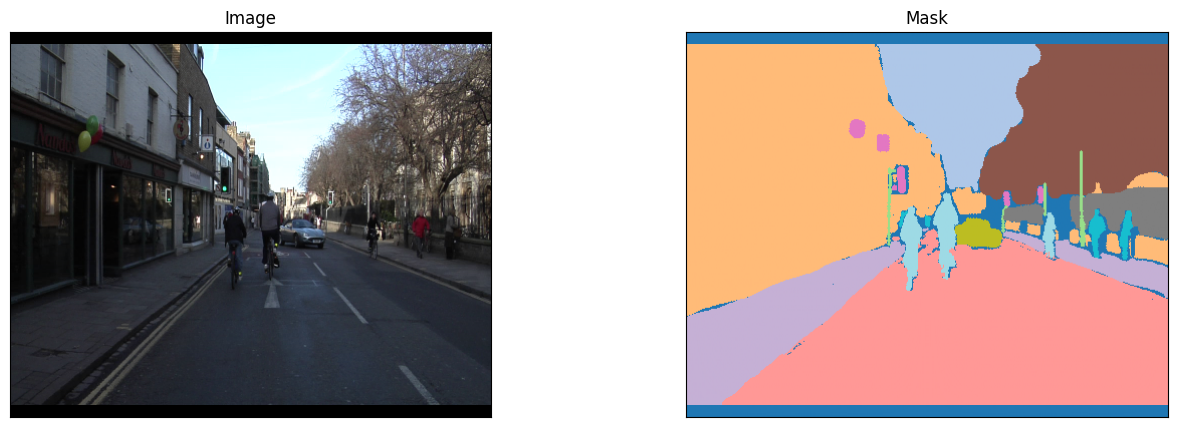

Mask shape: (384, 480)
[ 0  1  2  3  4  5  6  7  8  9 10 11]


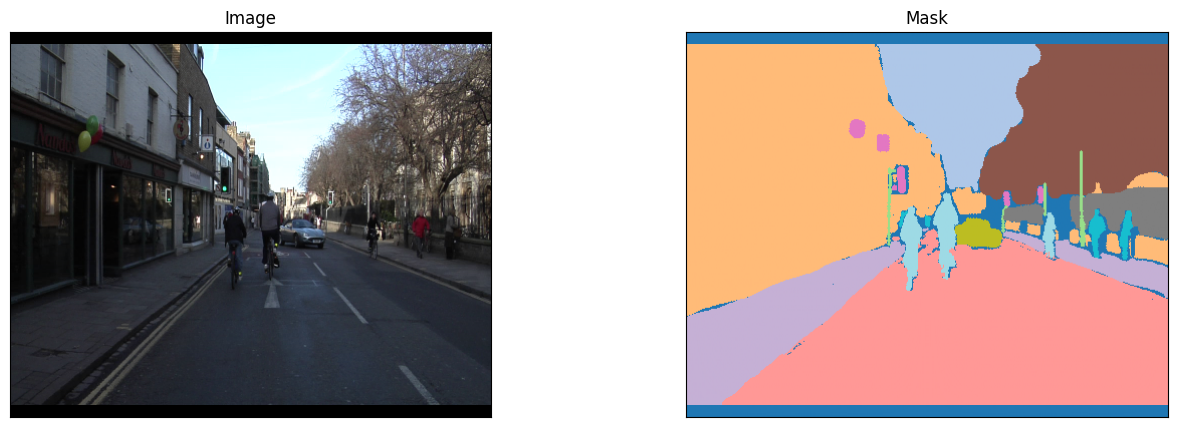

Mask shape: (384, 480)
[ 0  1  2  3  4  5  6  7  8  9 10 11]


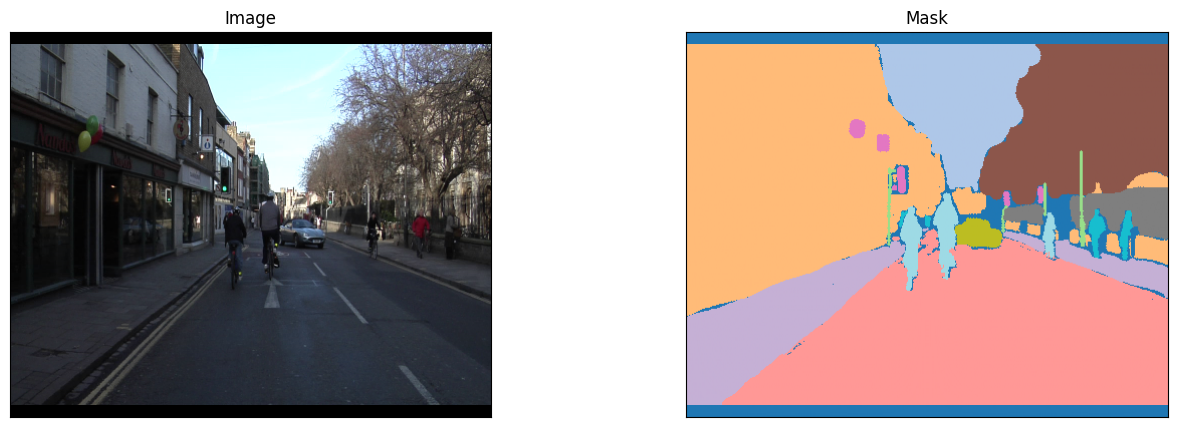

In [28]:
# Visualize resulted augmented images and masks
augmented_dataset = Dataset(
    x_valid_dir,
    y_valid_dir,
    augmentation=get_validation_augmentation(),
)

# Visualizing the same image with different random transforms
for i in range(3):
    image, mask = augmented_dataset[3]
    print(f"Mask shape: {mask.shape}")
    print(np.unique(mask))
    visualize(image=image, mask=mask)